# Soreal — Knowledge Graph RAG Agent

**Legal document analysis for SMBs** powered by SurrealDB + LangGraph + Ollama + LangSmith.

This notebook implements an agentic pipeline that:

1. **Ingests** unstructured legal documents and chunks them
2. **Extracts** legal entities (parties, clauses, obligations, risks…) via a local LLM (Ollama)
3. **Builds** a rich knowledge graph in SurrealDB with typed nodes and edges
4. **Answers questions** via graph-traversal RAG — with full source traceability
5. **Evolves** the graph during Q&A as new facts are discovered

### Prerequisites

| Dependency        | How to get it                                                                            |
| ----------------- | ---------------------------------------------------------------------------------------- |
| Python 3.10+      | Already installed                                                                        |
| `uv`              | `brew install uv`                                                                        |
| SurrealDB         | `brew install surrealdb/tap/surreal` then `surreal start --user root --pass root memory` |
| Ollama            | `brew install ollama` then `ollama pull llama3.1:8b`                                     |
| LangSmith API key | Free at https://smith.langchain.com — set in the config cell below                       |

Run the install cell once, restart the kernel, then continue.


In [24]:
# ── Phase 0, Cell 1: Install dependencies ────────────────────────────────────
import shutil, subprocess, sys

packages = [
    "langchain-surrealdb",
    "langchain-ollama",
    "langchain-huggingface",
    "langchain-text-splitters",
    "langgraph",
    "langsmith",
    "surrealdb",
    "sentence-transformers",
    "langchain-core",
    "langchain-community",
    "pandas",
    "python-dotenv",
]

if not shutil.which("uv"):
    raise RuntimeError("uv is not installed. Run: brew install uv")

cmd = ["uv", "pip", "install", "--python", sys.executable, "--upgrade", *packages]
print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True)
print("\n✅  Install complete. Restart the kernel before running the next cell.")

Running: uv pip install --python /Users/eldarutiushev/Projects/Soreal/.venv/bin/python --upgrade langchain-surrealdb langchain-ollama langchain-huggingface langchain-text-splitters langgraph langsmith surrealdb sentence-transformers langchain-core langchain-community pandas python-dotenv

✅  Install complete. Restart the kernel before running the next cell.


Resolved 81 packages in 657ms
Audited 81 packages in 2ms


## Phase 0 — Configuration & Readiness


In [25]:
# ── Phase 0, Cell 2: LangSmith + environment configuration ───────────────────
import os

from dotenv import load_dotenv

load_dotenv()

# LangSmith observability — set your API key here or via env var
os.environ.setdefault("LANGCHAIN_TRACING_V2", "true")
os.environ.setdefault("LANGCHAIN_PROJECT", "soreal-kg-agent")
# Uncomment and paste your key, or export LANGCHAIN_API_KEY before launching:
# os.environ["LANGCHAIN_API_KEY"] = "ls__..."

# SurrealDB
SURREAL_URL = os.getenv("SURREAL_URL", "ws://localhost:8000/rpc")
SURREAL_USERNAME = os.getenv("SURREAL_USERNAME", "root")
SURREAL_PASSWORD = os.getenv("SURREAL_PASSWORD", "root")
SURREAL_NAMESPACE = os.getenv("SURREAL_NAMESPACE", "soreal")
SURREAL_DATABASE = os.getenv("SURREAL_DATABASE", "kg")

# Ollama
OLLAMA_MODEL = os.getenv("OLLAMA_MODEL", "llama3.1:8b")
OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434")

# Embeddings
EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"
EMBEDDING_DIM = 384

print("Configuration loaded.")
print(f"  SurrealDB:  {SURREAL_URL}")
print(f"  Ollama:     {OLLAMA_BASE_URL} / {OLLAMA_MODEL}")
print(f"  LangSmith:  project={os.environ.get('LANGCHAIN_PROJECT')}")

Configuration loaded.
  SurrealDB:  ws://localhost:8000/rpc
  Ollama:     http://localhost:11434 / llama3.1:8b
  LangSmith:  project=soreal-kg-agent


In [26]:
# ── Phase 0, Cell 3: Readiness checks & connections ──────────────────────────
import socket, time, json
from urllib.parse import urlparse
import urllib.request

# --- SurrealDB check ---
def wait_for_surreal(url: str, timeout: float = 15.0) -> None:
    parsed = urlparse(url)
    host = parsed.hostname or "localhost"
    port = parsed.port or 8000
    deadline = time.time() + timeout
    last_err = None
    while time.time() < deadline:
        try:
            with socket.create_connection((host, port), timeout=2):
                return
        except OSError as e:
            last_err = e
            time.sleep(0.5)
    raise ConnectionError(
        f"SurrealDB not reachable at {url}. Start it in a separate terminal."
    ) from last_err

wait_for_surreal(SURREAL_URL)
print(f"✅  SurrealDB reachable at {SURREAL_URL}")

# --- Ollama check ---
def check_ollama(base_url: str, model: str) -> None:
    try:
        req = urllib.request.Request(f"{base_url}/api/tags")
        with urllib.request.urlopen(req, timeout=5) as resp:
            data = json.loads(resp.read())
            names = [m.get("name", "") for m in data.get("models", [])]
            if not any(model in n for n in names):
                print(f"⚠️  Model '{model}' not found. Available: {names}")
                print(f"   Run: ollama pull {model}")
            else:
                print(f"✅  Ollama ready with model {model}")
    except Exception as e:
        raise ConnectionError(
            f"Ollama not reachable at {base_url}. Start it with: ollama serve"
        ) from e

check_ollama(OLLAMA_BASE_URL, OLLAMA_MODEL)

# --- Connect to SurrealDB ---
from surrealdb import Surreal

conn = Surreal(SURREAL_URL)
conn.signin({"username": SURREAL_USERNAME, "password": SURREAL_PASSWORD})
conn.use(SURREAL_NAMESPACE, SURREAL_DATABASE)
print(f"✅  Connected: ns={SURREAL_NAMESPACE} db={SURREAL_DATABASE}")

# --- Embeddings ---
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)
print(f"✅  Embedding model loaded: {EMBEDDING_MODEL} (dim={EMBEDDING_DIM})")

# --- LLM ---
from langchain_ollama import ChatOllama

llm = ChatOllama(model=OLLAMA_MODEL, base_url=OLLAMA_BASE_URL, temperature=0)
print(f"✅  LLM ready: {OLLAMA_MODEL}")

✅  SurrealDB reachable at ws://localhost:8000/rpc
✅  Ollama ready with model llama3.1:8b
✅  Connected: ns=soreal db=kg
✅  Embedding model loaded: BAAI/bge-small-en-v1.5 (dim=384)
✅  LLM ready: llama3.1:8b


## Phase 1 — SurrealDB Schema & Agent Tools

Define the legal knowledge graph schema and the tools the agent will use.


In [27]:
# ── Phase 1, Cell 4: Define SurrealDB legal document schema ──────────────────

SCHEMA_STATEMENTS = [
    # ── Document structure ──
    "DEFINE TABLE IF NOT EXISTS document SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label    ON document TYPE string",
    "DEFINE FIELD IF NOT EXISTS doc_type ON document TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS vector   ON document TYPE option<array<float>>",

    "DEFINE TABLE IF NOT EXISTS document_version SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label          ON document_version TYPE string",
    "DEFINE FIELD IF NOT EXISTS version_number ON document_version TYPE option<string>",

    "DEFINE TABLE IF NOT EXISTS section SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label          ON section TYPE string",
    "DEFINE FIELD IF NOT EXISTS section_number ON section TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS vector         ON section TYPE option<array<float>>",

    "DEFINE TABLE IF NOT EXISTS paragraph SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS content         ON paragraph TYPE string",
    "DEFINE FIELD IF NOT EXISTS paragraph_index ON paragraph TYPE option<int>",
    "DEFINE FIELD IF NOT EXISTS vector          ON paragraph TYPE option<array<float>>",

    "DEFINE TABLE IF NOT EXISTS chunk SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS content     ON chunk TYPE string",
    "DEFINE FIELD IF NOT EXISTS source      ON chunk TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS chunk_index ON chunk TYPE int",
    "DEFINE FIELD IF NOT EXISTS vector      ON chunk TYPE option<array<float>>",

    # ── Legal semantics ──
    "DEFINE TABLE IF NOT EXISTS clause SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label   ON clause TYPE string",
    "DEFINE FIELD IF NOT EXISTS content ON clause TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS vector  ON clause TYPE option<array<float>>",

    "DEFINE TABLE IF NOT EXISTS obligation SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label       ON obligation TYPE string",
    "DEFINE FIELD IF NOT EXISTS description ON obligation TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS vector      ON obligation TYPE option<array<float>>",

    "DEFINE TABLE IF NOT EXISTS legal_right SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label       ON legal_right TYPE string",
    "DEFINE FIELD IF NOT EXISTS description ON legal_right TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS vector      ON legal_right TYPE option<array<float>>",

    "DEFINE TABLE IF NOT EXISTS restriction SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label       ON restriction TYPE string",
    "DEFINE FIELD IF NOT EXISTS description ON restriction TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS vector      ON restriction TYPE option<array<float>>",

    "DEFINE TABLE IF NOT EXISTS condition SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label       ON condition TYPE string",
    "DEFINE FIELD IF NOT EXISTS description ON condition TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS vector      ON condition TYPE option<array<float>>",

    "DEFINE TABLE IF NOT EXISTS definition SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label   ON definition TYPE string",
    "DEFINE FIELD IF NOT EXISTS meaning ON definition TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS vector  ON definition TYPE option<array<float>>",

    # ── Parties ──
    "DEFINE TABLE IF NOT EXISTS party SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label      ON party TYPE string",
    "DEFINE FIELD IF NOT EXISTS party_type ON party TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS vector     ON party TYPE option<array<float>>",

    "DEFINE TABLE IF NOT EXISTS representative SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label ON representative TYPE string",
    "DEFINE FIELD IF NOT EXISTS role  ON representative TYPE option<string>",

    # ── Temporal ──
    "DEFINE TABLE IF NOT EXISTS term SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label      ON term TYPE string",
    "DEFINE FIELD IF NOT EXISTS start_date ON term TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS end_date   ON term TYPE option<string>",

    "DEFINE TABLE IF NOT EXISTS key_date SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label      ON key_date TYPE string",
    "DEFINE FIELD IF NOT EXISTS date_value ON key_date TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS date_type  ON key_date TYPE option<string>",

    "DEFINE TABLE IF NOT EXISTS amendment SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label       ON amendment TYPE string",
    "DEFINE FIELD IF NOT EXISTS description ON amendment TYPE option<string>",

    # ── Financial ──
    "DEFINE TABLE IF NOT EXISTS payment_term SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label       ON payment_term TYPE string",
    "DEFINE FIELD IF NOT EXISTS description ON payment_term TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS amount      ON payment_term TYPE option<string>",

    "DEFINE TABLE IF NOT EXISTS liability_cap SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label       ON liability_cap TYPE string",
    "DEFINE FIELD IF NOT EXISTS cap_amount  ON liability_cap TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS description ON liability_cap TYPE option<string>",

    "DEFINE TABLE IF NOT EXISTS fee SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label       ON fee TYPE string",
    "DEFINE FIELD IF NOT EXISTS amount      ON fee TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS description ON fee TYPE option<string>",

    # ── Risk & Analysis ──
    "DEFINE TABLE IF NOT EXISTS risk SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label       ON risk TYPE string",
    "DEFINE FIELD IF NOT EXISTS severity    ON risk TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS description ON risk TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS vector      ON risk TYPE option<array<float>>",

    "DEFINE TABLE IF NOT EXISTS compliance_requirement SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label       ON compliance_requirement TYPE string",
    "DEFINE FIELD IF NOT EXISTS description ON compliance_requirement TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS vector      ON compliance_requirement TYPE option<array<float>>",

    "DEFINE TABLE IF NOT EXISTS flag SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label       ON flag TYPE string",
    "DEFINE FIELD IF NOT EXISTS flag_type   ON flag TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS description ON flag TYPE option<string>",

    # ── Comparison & Templates ──
    "DEFINE TABLE IF NOT EXISTS template SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label       ON template TYPE string",
    "DEFINE FIELD IF NOT EXISTS description ON template TYPE option<string>",

    "DEFINE TABLE IF NOT EXISTS playbook SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label       ON playbook TYPE string",
    "DEFINE FIELD IF NOT EXISTS description ON playbook TYPE option<string>",

    "DEFINE TABLE IF NOT EXISTS precedent SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS label  ON precedent TYPE string",
    "DEFINE FIELD IF NOT EXISTS source ON precedent TYPE option<string>",

    # ── Edge tables (relations) ──
    # Document structure
    "DEFINE TABLE IF NOT EXISTS has_version       TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON has_version TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS contains_section  TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON contains_section TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS contains          TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON contains TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS has_child         TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON has_child TYPE option<string>",

    # Legal semantics
    "DEFINE TABLE IF NOT EXISTS contains_clause   TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON contains_clause TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS creates           TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON creates TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS grants            TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON grants TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS imposes           TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON imposes TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS depends_on        TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON depends_on TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS references_term   TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON references_term TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS cross_references  TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON cross_references TYPE option<string>",

    # Parties
    "DEFINE TABLE IF NOT EXISTS involves          TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON involves TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS binds             TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON binds TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS benefits          TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON benefits TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS signs             TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON signs TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS represented_by    TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON represented_by TYPE option<string>",

    # Temporal
    "DEFINE TABLE IF NOT EXISTS has_term          TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON has_term TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS has_key_date      TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON has_key_date TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS due_by            TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON due_by TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS amended_by        TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON amended_by TYPE option<string>",

    # Financial
    "DEFINE TABLE IF NOT EXISTS has_payment       TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON has_payment TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS sets_liability    TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON sets_liability TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS has_fee           TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON has_fee TYPE option<string>",

    # Risk & Analysis
    "DEFINE TABLE IF NOT EXISTS has_risk          TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON has_risk TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS requires_compliance TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON requires_compliance TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS flagged_as        TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON flagged_as TYPE option<string>",

    # Comparison & Templates
    "DEFINE TABLE IF NOT EXISTS derived_from      TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON derived_from TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS deviates_from     TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON deviates_from TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS related_to        TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON related_to TYPE option<string>",
    "DEFINE FIELD IF NOT EXISTS type         ON related_to TYPE option<string>",
    "DEFINE TABLE IF NOT EXISTS similar_to        TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON similar_to TYPE option<string>",

    # Source referencing
    "DEFINE TABLE IF NOT EXISTS sourced_from      TYPE RELATION SCHEMAFULL",
    "DEFINE FIELD IF NOT EXISTS source_chunk ON sourced_from TYPE option<string>",

    # ── Vector indexes (HNSW) ──
    "DEFINE INDEX IF NOT EXISTS idx_party_vec       ON party       FIELDS vector HNSW DIMENSION 384 DIST COSINE",
    "DEFINE INDEX IF NOT EXISTS idx_clause_vec      ON clause      FIELDS vector HNSW DIMENSION 384 DIST COSINE",
    "DEFINE INDEX IF NOT EXISTS idx_obligation_vec  ON obligation  FIELDS vector HNSW DIMENSION 384 DIST COSINE",
    "DEFINE INDEX IF NOT EXISTS idx_right_vec       ON legal_right FIELDS vector HNSW DIMENSION 384 DIST COSINE",
    "DEFINE INDEX IF NOT EXISTS idx_restriction_vec ON restriction FIELDS vector HNSW DIMENSION 384 DIST COSINE",
    "DEFINE INDEX IF NOT EXISTS idx_risk_vec        ON risk        FIELDS vector HNSW DIMENSION 384 DIST COSINE",
    "DEFINE INDEX IF NOT EXISTS idx_condition_vec   ON condition   FIELDS vector HNSW DIMENSION 384 DIST COSINE",
    "DEFINE INDEX IF NOT EXISTS idx_definition_vec  ON definition  FIELDS vector HNSW DIMENSION 384 DIST COSINE",
    "DEFINE INDEX IF NOT EXISTS idx_compliance_vec  ON compliance_requirement FIELDS vector HNSW DIMENSION 384 DIST COSINE",
    "DEFINE INDEX IF NOT EXISTS idx_section_vec     ON section     FIELDS vector HNSW DIMENSION 384 DIST COSINE",
    "DEFINE INDEX IF NOT EXISTS idx_chunk_vec       ON chunk       FIELDS vector HNSW DIMENSION 384 DIST COSINE",
]

for stmt in SCHEMA_STATEMENTS:
    conn.query(stmt + ";")

print("✅  Schema defined. Verifying...")
info = conn.query("INFO FOR DB;")
print(json.dumps(info, indent=2)[:3000])


✅  Schema defined. Verifying...
{
  "accesses": {},
  "analyzers": {},
  "apis": {},
  "buckets": {},
  "configs": {},
  "functions": {},
  "models": {},
  "modules": {},
  "params": {},
  "sequences": {},
  "tables": {
    "action": "DEFINE TABLE action TYPE NORMAL SCHEMAFULL PERMISSIONS NONE",
    "amended_by": "DEFINE TABLE amended_by TYPE RELATION SCHEMAFULL PERMISSIONS NONE",
    "amendment": "DEFINE TABLE amendment TYPE NORMAL SCHEMAFULL PERMISSIONS NONE",
    "benefits": "DEFINE TABLE benefits TYPE RELATION SCHEMAFULL PERMISSIONS NONE",
    "binds": "DEFINE TABLE binds TYPE RELATION SCHEMAFULL PERMISSIONS NONE",
    "character": "DEFINE TABLE character TYPE NORMAL SCHEMAFULL PERMISSIONS NONE",
    "chunk": "DEFINE TABLE chunk TYPE NORMAL SCHEMAFULL PERMISSIONS NONE",
    "clause": "DEFINE TABLE clause TYPE NORMAL SCHEMAFULL PERMISSIONS NONE",
    "compliance_requirement": "DEFINE TABLE compliance_requirement TYPE NORMAL SCHEMAFULL PERMISSIONS NONE",
    "condition": "DEFINE TABL

In [28]:
# ── Phase 1, Cell 5: Define LangChain tools & prompts for legal KG ──────────

from langchain_core.tools import tool
from langchain_text_splitters import RecursiveCharacterTextSplitter

# ── Valid entity & predicate catalogues ─────────────────────────────────────

VALID_ENTITY_TYPES = [
    "party", "representative", "clause", "obligation", "right", "restriction",
    "condition", "definition", "key_date", "payment_term", "fee",
    "liability_cap", "risk", "compliance_requirement", "section", "flag",
    "amendment", "document", "term",
]

ENTITY_TYPE_TO_TABLE = {t: t for t in VALID_ENTITY_TYPES}
ENTITY_TYPE_TO_TABLE["right"] = "legal_right"        # avoid SurrealQL keyword

VECTORIZED_TABLES = [
    "party", "clause", "obligation", "legal_right", "restriction",
    "risk", "condition", "definition", "compliance_requirement",
    "section", "chunk",
]

VALID_PREDICATES = [
    "contains_section", "contains_clause", "contains", "has_child",
    "creates", "grants", "imposes", "depends_on", "references_term",
    "cross_references", "involves", "binds", "benefits", "signs",
    "represented_by", "has_term", "has_key_date", "due_by", "amended_by",
    "has_payment", "sets_liability", "has_fee", "has_risk",
    "requires_compliance", "flagged_as", "derived_from", "deviates_from",
    "related_to", "similar_to", "sourced_from", "has_version",
]

# ── Prompts ─────────────────────────────────────────────────────────────────

LEGAL_NER_PROMPT = """\
You are a legal‑document NER system.
Given a text chunk from a contract or legal document, extract every entity.

Allowed entity types: {entity_types}

Return **only** valid JSON – a list of objects:
[
  {{"entity_type": "...", "name": "...", "properties": {{...}} }}
]

For each entity:
- `name` is a short, descriptive label.
- `properties` may include fields like description, amount, severity, date_value, etc.

If a chunk has no entities, return an empty list: []

Text chunk:
\"\"\"
{text}
\"\"\"
"""

LEGAL_TRIPLET_PROMPT = """\
You are a legal‑document relation extraction system.
Given extracted entities and the original text chunk, produce a list of
(subject, predicate, object) triplets that capture relationships.

Entities found so far:
{entities}

Allowed predicates: {predicates}

Return **only** valid JSON – a list of triplet objects:
[
  {{"subject": "entity_name", "predicate": "...", "object": "entity_name",
    "source_chunk": "chunk_id"}}
]

Rules:
- Only use entities from the list above as subject / object.
- Only use predicates from the allowed list.
- Each triplet must include the source_chunk id for traceability.

Text chunk (id = {chunk_id}):
\"\"\"
{text}
\"\"\"
"""

# ── Tool definitions ────────────────────────────────────────────────────────

@tool
def ingest_text(text: str, source: str = "legal_doc") -> str:
    """Split a legal document into overlapping chunks, embed and store them."""
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=800, chunk_overlap=100,
        separators=["\n\n", "\n", ". ", " "]
    )
    chunks = splitter.split_text(text)
    records = []
    for i, c in enumerate(chunks):
        vec = embeddings.embed_query(c)
        chunk_id = f"chunk:{source}_{i}"
        conn.query(
            "CREATE type::thing($tb, $id) SET content=$content, "
            "source=$source, chunk_index=$idx, vector=$vec;",
            {"tb": "chunk", "id": f"{source}_{i}",
             "content": c, "source": source, "idx": i, "vec": vec}
        )
        records.append({"chunk_id": chunk_id, "length": len(c)})
    return json.dumps({"status": "ok", "chunks_created": len(records),
                        "details": records})


@tool
def extract_legal_entities(chunks_json: str) -> str:
    """Run legal NER over every stored chunk and return merged entities JSON."""
    import re as _re
    chunks_info = json.loads(chunks_json)
    all_entities = []
    seen = set()
    for info in chunks_info.get("details", chunks_info):
        cid = info["chunk_id"] if isinstance(info, dict) else info
        short = cid.split(":")[-1] if ":" in cid else cid
        rows = conn.query(
            "SELECT content FROM type::thing($tb, $id);",
            {"tb": "chunk", "id": short}
        )
        if not rows or not rows[0]:
            continue
        text = rows[0][0]["content"] if isinstance(rows[0], list) else rows[0].get("content", "")
        prompt = LEGAL_NER_PROMPT.format(
            entity_types=", ".join(VALID_ENTITY_TYPES), text=text
        )
        resp = llm.invoke(prompt)
        raw = resp.content if hasattr(resp, "content") else str(resp)
        # extract JSON array
        match = _re.search(r"\[.*\]", raw, _re.DOTALL)
        if not match:
            continue
        try:
            ents = json.loads(match.group())
        except json.JSONDecodeError:
            continue
        for e in ents:
            key = (e.get("entity_type", ""), e.get("name", ""))
            if key not in seen:
                seen.add(key)
                all_entities.append(e)
    return json.dumps(all_entities)


@tool
def form_legal_triplets(entities_json: str, chunks_json: str) -> str:
    """Extract relation triplets between the given entities for every chunk."""
    import re as _re
    entities = json.loads(entities_json)
    chunks_info = json.loads(chunks_json)
    all_triplets = []
    for info in chunks_info.get("details", chunks_info):
        cid = info["chunk_id"] if isinstance(info, dict) else info
        short = cid.split(":")[-1] if ":" in cid else cid
        rows = conn.query(
            "SELECT content FROM type::thing($tb, $id);",
            {"tb": "chunk", "id": short}
        )
        if not rows or not rows[0]:
            continue
        text = rows[0][0]["content"] if isinstance(rows[0], list) else rows[0].get("content", "")
        prompt = LEGAL_TRIPLET_PROMPT.format(
            entities=json.dumps(entities[:60]),
            predicates=", ".join(VALID_PREDICATES),
            chunk_id=cid, text=text,
        )
        resp = llm.invoke(prompt)
        raw = resp.content if hasattr(resp, "content") else str(resp)
        match = _re.search(r"\[.*\]", raw, _re.DOTALL)
        if not match:
            continue
        try:
            trips = json.loads(match.group())
        except json.JSONDecodeError:
            continue
        for t in trips:
            if t.get("predicate") in VALID_PREDICATES:
                all_triplets.append(t)
    return json.dumps(all_triplets)


def _make_id(name: str) -> str:
    """Sanitise an entity name into a SurrealDB record-id fragment."""
    return name.lower().replace(" ", "_").replace("'", "")[:60]


@tool
def load_entities_and_triplets(entities_json: str, triplets_json: str) -> str:
    """Upsert legal entities (with vectors) and create relation edges."""
    entities = json.loads(entities_json)
    triplets = json.loads(triplets_json)

    ent_count = 0
    for e in entities:
        etype = e.get("entity_type", "unknown")
        table = ENTITY_TYPE_TO_TABLE.get(etype)
        if not table:
            continue
        rid = _make_id(e["name"])
        props = e.get("properties", {})
        label = e.get("name", rid)
        vec = embeddings.embed_query(label) if table in VECTORIZED_TABLES else None
        fields = "label=$label, vector=$vec" if vec else "label=$label"
        for k, v in props.items():
            fields += f", {k}=$prop_{k}"
        params = {"tb": table, "id": rid, "label": label, "vec": vec}
        for k, v in props.items():
            params[f"prop_{k}"] = v
        conn.query(f"CREATE type::thing($tb, $id) SET {fields};", params)
        ent_count += 1

    edge_count = 0
    for t in triplets:
        pred = t.get("predicate")
        if pred not in VALID_PREDICATES:
            continue
        subj_name = t.get("subject", "")
        obj_name = t.get("object", "")
        # find entity types
        subj_type = next((e["entity_type"] for e in entities if e["name"] == subj_name), None)
        obj_type = next((e["entity_type"] for e in entities if e["name"] == obj_name), None)
        if not subj_type or not obj_type:
            continue
        subj_table = ENTITY_TYPE_TO_TABLE.get(subj_type)
        obj_table = ENTITY_TYPE_TO_TABLE.get(obj_type)
        if not subj_table or not obj_table:
            continue
        subj_id = f"{subj_table}:{_make_id(subj_name)}"
        obj_id = f"{obj_table}:{_make_id(obj_name)}"
        sc = t.get("source_chunk", "")
        conn.query(
            f"RELATE type::thing(${{'from'}}) ->{pred}-> type::thing($to) "
            f"SET source_chunk=$sc;",
            {"from": subj_id, "to": obj_id, "sc": sc}
        )
        edge_count += 1

    return json.dumps({"entities_loaded": ent_count, "edges_created": edge_count})


@tool
def search_graph(query: str, top_k: int = 5) -> str:
    """Semantic vector search across all vectorised KG tables + graph walk."""
    qvec = embeddings.embed_query(query)
    results = []
    for tbl in VECTORIZED_TABLES:
        rows = conn.query(
            f"SELECT *, vector::similarity::cosine(vector, $qvec) AS score "
            f"FROM {tbl} WHERE vector != NONE "
            f"ORDER BY score DESC LIMIT $k;",
            {"qvec": qvec, "k": top_k}
        )
        flat = rows[0] if rows and isinstance(rows[0], list) else rows
        for r in (flat or []):
            results.append({"table": tbl, "id": str(r.get("id", "")),
                            "label": r.get("label", r.get("content", "")),
                            "score": r.get("score", 0)})
    results.sort(key=lambda x: x["score"], reverse=True)
    top = results[:top_k]
    # graph walk: one hop out from each result
    enriched = []
    for r in top:
        rid = r["id"]
        out_rows = conn.query(f"SELECT ->? AS rels FROM {rid};")
        in_rows = conn.query(f"SELECT <-? AS rels FROM {rid};")
        r["outgoing"] = out_rows[0] if out_rows else []
        r["incoming"] = in_rows[0] if in_rows else []
        enriched.append(r)
    return json.dumps(enriched, default=str)


@tool
def mutate_graph(surql: str) -> str:
    """Execute a SurrealQL mutation (CREATE / RELATE / UPDATE / DELETE)."""
    blocked = ["REMOVE", "DROP", "DEFINE", "INFO"]
    upper = surql.upper()
    for b in blocked:
        if b in upper:
            return json.dumps({"error": f"Blocked keyword: {b}"})
    res = conn.query(surql)
    return json.dumps(res, default=str)


@tool
def get_graph_summary() -> str:
    """Return record counts for every node and edge table in the KG."""
    tables = (
        [t for t in ENTITY_TYPE_TO_TABLE.values()]
        + ["chunk", "document", "paragraph"]
        + VALID_PREDICATES
    )
    counts = {}
    for t in set(tables):
        try:
            r = conn.query(f"SELECT count() FROM {t} GROUP ALL;")
            flat = r[0] if r and isinstance(r[0], list) else r
            counts[t] = flat[0].get("count", 0) if flat else 0
        except Exception:
            counts[t] = 0
    return json.dumps(counts)


ALL_TOOLS = [
    ingest_text,
    extract_legal_entities,
    form_legal_triplets,
    load_entities_and_triplets,
    search_graph,
    mutate_graph,
    get_graph_summary,
]

print("✅  7 legal‑KG tools defined")
print("   Entity types:", len(VALID_ENTITY_TYPES))
print("   Predicates  :", len(VALID_PREDICATES))


✅  7 legal‑KG tools defined
   Entity types: 19
   Predicates  : 31


## Phase 2 — LangGraph Agent

A `StateGraph` with routed entry handling for two modes:

- **Ingest pipeline**: deterministic ingestion → entity extraction → triplet formation → graph loading (no human review)
- **Interactive Q&A**: backed by SurrealDB graph search and graph mutation tools


In [29]:
# ── Phase 2, Cell 6: Agent state & graph definition ──────────────────────────
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage


class AgentState(TypedDict, total=False):
    messages: Annotated[list, add_messages]
    chunks_json: str          # JSON from ingest_text
    entities_json: str        # JSON from extract_legal_entities
    triplets_json: str        # JSON from form_legal_triplets
    phase: str


QUERY_TOOLS = [search_graph, mutate_graph, get_graph_summary]


def _latest_human_message(state: AgentState):
    return next(
        (msg for msg in reversed(state.get("messages", []))
         if isinstance(msg, HumanMessage)),
        None,
    )


def entry_node(state: AgentState) -> dict:
    return {}


def route_from_entry(state: AgentState) -> str:
    latest_human = _latest_human_message(state)
    content = latest_human.content if latest_human else ""
    if "Analyze this legal document:" in content:
        return "ingest"
    return "query"


# ── Ingest pipeline (no human review) ──


def ingest_node(state: AgentState) -> dict:
    latest_human = _latest_human_message(state)
    if latest_human is None:
        return {"messages": [AIMessage(content="No input text found.")], "phase": "ingest"}

    content = latest_human.content
    marker = "Analyze this legal document:"
    text = content.split(marker, 1)[1].strip() if marker in content else content.strip()
    chunks_json = ingest_text.invoke({"text": text, "source": "legal_doc"})
    info = json.loads(chunks_json)
    return {
        "chunks_json": chunks_json,
        "messages": [AIMessage(content=f"Stored {info.get('chunks_created', 0)} chunks in SurrealDB.")],
        "phase": "ingest_completed",
    }


def extract_entities_node(state: AgentState) -> dict:
    chunks_json = state.get("chunks_json", "")
    if not chunks_json:
        return {
            "entities_json": "[]",
            "messages": [AIMessage(content="No chunks available for entity extraction.")],
            "phase": "extract_completed",
        }
    entities_json = extract_legal_entities.invoke({"chunks_json": chunks_json})
    count = len(json.loads(entities_json))
    return {
        "entities_json": entities_json,
        "messages": [AIMessage(content=f"Extracted {count} legal entities.")],
        "phase": "extract_completed",
    }


def form_triplets_node(state: AgentState) -> dict:
    entities_json = state.get("entities_json", "[]")
    chunks_json = state.get("chunks_json", "")
    triplets_json = form_legal_triplets.invoke(
        {"entities_json": entities_json, "chunks_json": chunks_json}
    )
    count = len(json.loads(triplets_json))
    return {
        "triplets_json": triplets_json,
        "messages": [AIMessage(content=f"Formed {count} relation triplets.")],
        "phase": "triplets_completed",
    }


def load_node(state: AgentState) -> dict:
    entities_json = state.get("entities_json", "[]")
    triplets_json = state.get("triplets_json", "[]")
    result = load_entities_and_triplets.invoke(
        {"entities_json": entities_json, "triplets_json": triplets_json}
    )
    info = json.loads(result)
    return {
        "messages": [AIMessage(
            content=f"Knowledge graph updated: {info.get('entities_loaded', 0)} entities, "
                    f"{info.get('edges_created', 0)} edges."
        )],
        "phase": "loaded",
    }


# ── Query loop ──


def query_node(state: AgentState) -> dict:
    bound = llm.bind_tools(QUERY_TOOLS)
    system = SystemMessage(
        content=(
            "You are a legal-document analysis assistant backed by a knowledge graph in SurrealDB. "
            "RULES:\n"
            "1. For counting or overview questions ('how many …', 'list all …'), "
            "call get_graph_summary FIRST.\n"
            "2. For specific questions about parties, clauses, obligations, etc., use search_graph.\n"
            "3. If the user provides corrections or new facts, use mutate_graph.\n"
            "4. ALWAYS answer based on data returned by tools — do NOT guess or give generic definitions.\n"
            "5. Cite the source chunk ID when possible for traceability."
        )
    )
    response = bound.invoke([system] + state.get("messages", []))
    return {"messages": [response], "phase": "query"}


query_tools_executor = ToolNode(QUERY_TOOLS)


def should_continue_query(state: AgentState) -> str:
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "query_tools"
    return END


# ── Build graph ──

workflow = StateGraph(AgentState)

workflow.add_node("entry", entry_node)
workflow.add_node("ingest", ingest_node)
workflow.add_node("extract_entities", extract_entities_node)
workflow.add_node("form_triplets", form_triplets_node)
workflow.add_node("load", load_node)
workflow.add_node("query", query_node)
workflow.add_node("query_tools", query_tools_executor)

workflow.add_edge(START, "entry")
workflow.add_conditional_edges("entry", route_from_entry, {"ingest": "ingest", "query": "query"})
workflow.add_edge("ingest", "extract_entities")
workflow.add_edge("extract_entities", "form_triplets")
workflow.add_edge("form_triplets", "load")
workflow.add_edge("load", END)
workflow.add_conditional_edges("query", should_continue_query, {"query_tools": "query_tools", END: END})
workflow.add_edge("query_tools", "query")

checkpointer = MemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

print("✅  LangGraph agent compiled (no human review)")
print(f"   Nodes: {list(graph.nodes.keys())}")


✅  LangGraph agent compiled (no human review)
   Nodes: ['__start__', 'entry', 'ingest', 'extract_entities', 'form_triplets', 'load', 'query', 'query_tools']


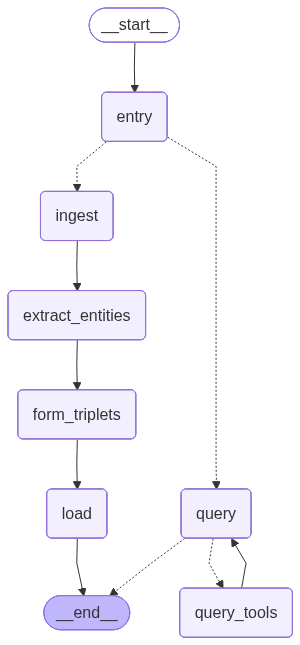

In [30]:
# Visualise the agent graph
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

## Phase 3 — Ingest & Build the Knowledge Graph

Load a legal document from `legal_doc.txt`, send it through the pipeline:

1. **Ingest** — chunk the document and embed chunks into SurrealDB
2. **Extract entities** — NER over each chunk (parties, clauses, obligations, …)
3. **Form triplets** — relation extraction between entities
4. **Load** — upsert entities + edges into the graph


In [31]:
# ── Phase 3, Cell 8: Load legal_doc.txt and run ingestion pipeline ─────────────
import uuid

with open("legal_doc.txt", "r") as f:
    legal_text = f.read()

print(f"Loaded legal_doc.txt ({len(legal_text)} chars, {len(legal_text.splitlines())} lines)\n")

thread_config = {"configurable": {"thread_id": str(uuid.uuid4())}}

for event in graph.stream(
    {"messages": [HumanMessage(content=f"Analyze this legal document:\n\n{legal_text}")]},
    config=thread_config,
    stream_mode="values",
):
    phase = event.get("phase", "unknown")
    print(f"\n[phase={phase}]")
    last_message = event["messages"][-1]
    content = str(getattr(last_message, "content", "")).strip()
    if content:
        print(content[:400])

print("\n─── Pipeline completed ───")


Loaded legal_doc.txt (2458 chars, 32 lines)


[phase=unknown]
Analyze this legal document:

1. Term. This Agreement shall be effective as of the Effective Date and shall have
an initial term of ____ (__) months. Upon the expiration of such term (or any renewal
term), this Agreement shall automatically renew for additional ______ (__) month
periods unless either party notifies the other party at least thirty (30) days prior to the
applicable renewal date of i


Exception: {'cause': None, 'code': -32000, 'kind': 'Validation', 'message': 'Parse error: Invalid function/constant path, did you maybe mean `type::record`\n --> [1:8]\n  |\n1 | CREATE type::thing($tb, $id) SET content=$content, source=$source, chunk_inde...\n  |        ^^^^^^^^^^^\n'}

In [32]:
# ── Phase 3, Cell 9: Inspect pipeline artifacts ───────────────────────────────
import pandas as pd

state = graph.get_state(thread_config)

entities = json.loads(state.values.get("entities_json", "[]") or "[]")
triplets = json.loads(state.values.get("triplets_json", "[]") or "[]")

print(f"Phase: {state.values.get('phase', 'unknown')}")
print(f"Entities extracted: {len(entities)}")
print(f"Triplets formed:    {len(triplets)}")

if entities:
    print("\nEntity table:")
    display(pd.DataFrame([
        {"name": e.get("name", ""), "type": e.get("entity_type", ""),
         "props": str(e.get("properties", {}))[:80]}
        for e in entities
    ]))

if triplets:
    print("\nTriplet table:")
    display(pd.DataFrame(triplets[:30]))


Phase: unknown
Entities extracted: 0
Triplets formed:    0


In [33]:
# ── Phase 3, Cell 10: Quick graph summary after loading ───────────────────────
summary = json.loads(get_graph_summary.invoke({}))
non_zero = {k: v for k, v in sorted(summary.items()) if v > 0}
print("Graph tables with data:")
for tbl, cnt in non_zero.items():
    print(f"  {tbl:30s}: {cnt}")


Graph tables with data:
  chunk                         : 32


## Phase 5 — Knowledge Graph Verification

Query SurrealDB to confirm the knowledge graph was populated correctly.


In [34]:
# ── Phase 5, Cell 12: Verify KG contents ──────────────────────────────────────
import pandas as pd


def _rows(result):
    if not result:
        return []
    if isinstance(result[0], list):
        return result[0]
    return result


NODE_TABLES = list(set(ENTITY_TYPE_TO_TABLE.values())) + ["chunk", "document", "paragraph"]
EDGE_TABLES = VALID_PREDICATES


def verify_kg():
    """Print node and edge counts + sample data."""
    print("═══ Node Counts ═══")
    for table in sorted(NODE_TABLES):
        rows = _rows(conn.query(f"SELECT count() AS c FROM {table} GROUP ALL;"))
        count = rows[0].get("c", 0) if rows else 0
        if count > 0:
            print(f"  {table:30s}: {count}")

    print("\n═══ Edge Counts ═══")
    for table in sorted(EDGE_TABLES):
        rows = _rows(conn.query(f"SELECT count() AS c FROM {table} GROUP ALL;"))
        count = rows[0].get("c", 0) if rows else 0
        if count > 0:
            print(f"  {table:30s}: {count}")

    # Sample parties
    parties = _rows(conn.query("SELECT label, party_type FROM party;"))
    if parties:
        print("\n═══ Parties ═══")
        display(pd.DataFrame(parties))

    # Sample clauses
    clauses = _rows(conn.query("SELECT label FROM clause LIMIT 10;"))
    if clauses:
        print("\n═══ Clauses (sample) ═══")
        display(pd.DataFrame(clauses))

    # Sample obligations
    obligations = _rows(conn.query("SELECT label, description FROM obligation LIMIT 10;"))
    if obligations:
        print("\n═══ Obligations (sample) ═══")
        display(pd.DataFrame(obligations))


verify_kg()


═══ Node Counts ═══
  chunk                         : 32

═══ Edge Counts ═══


In [35]:
# Optional: inspect raw edge rows by relation table
for edge_table in ["involves", "creates", "grants", "imposes", "binds"]:
    rows = _rows(conn.query(f"SELECT * FROM {edge_table} LIMIT 5;"))
    if rows:
        print(f"\n=== {edge_table} ({len(rows)} shown) ===")
        print(json.dumps(rows, indent=2, default=str)[:600])


In [36]:
# ── Phase 5, Cell 13: Graph traversal example ─────────────────────────────────
# Demonstrate SurrealDB's native graph traversal capabilities


def traverse_example():
    """Show multi-hop graph traversal from each party."""
    parties = _rows(conn.query("SELECT label FROM party;"))
    if not parties:
        print("No parties found; run earlier cells first.")
        return

    for p in parties:
        label = p["label"]
        print(f"\n{'═' * 60}")
        print(f"Party: {label}")
        print(f"{'─' * 60}")

        # 1-hop: what obligations bind this party?
        obls = _rows(conn.query(
            "SELECT ->binds->obligation.label AS obligations FROM party WHERE label = $label;",
            {"label": label},
        ))
        if obls and obls[0].get("obligations"):
            print(f"  Obligations: {obls[0]['obligations']}")

        # 1-hop: what clauses involve this party?
        cls = _rows(conn.query(
            "SELECT <-involves<-clause.label AS clauses FROM party WHERE label = $label;",
            {"label": label},
        ))
        if cls and cls[0].get("clauses"):
            print(f"  Involved in clauses: {cls[0]['clauses']}")

        # 1-hop: rights granted to this party
        rights = _rows(conn.query(
            "SELECT ->grants->legal_right.label AS rights FROM party WHERE label = $label;",
            {"label": label},
        ))
        if rights and rights[0].get("rights"):
            print(f"  Rights: {rights[0]['rights']}")


traverse_example()


No parties found; run earlier cells first.


## Phase 6 — Graph-Traversal RAG Q&A

Ask investigative questions about the legal document. The agent will:

1. Find relevant entities via vector similarity
2. Traverse the knowledge graph for context
3. Generate a grounded answer with source citations

The agent can also **evolve** the graph — adding corrections or new facts during Q&A.


In [37]:
# ── Phase 6, Cell 14: Ask a question ──────────────────────────────────────────

def ask(question: str, config: dict):
    """Send a query-phase message to the agent and print the response."""
    print(f"❓  {question}\n")
    for event in graph.stream(
        {"messages": [HumanMessage(content=question)]},
        config=config,
        stream_mode="values",
    ):
        last_msg = event["messages"][-1]
        role = getattr(last_msg, "type", "unknown")
        content = str(getattr(last_msg, "content", ""))
        tool_calls = getattr(last_msg, "tool_calls", [])
        if tool_calls:
            print(f"  🔧 {[tc['name'] for tc in tool_calls]}")
        elif content and role == "ai":
            print(f"  💬 {content}\n")


# Legal document questions
ask("Who are the parties in this agreement?", thread_config)
ask("What obligations does the Vendor have under this contract?", thread_config)
ask("What happens when the agreement term expires?", thread_config)


❓  Who are the parties in this agreement?

  🔧 ['search_graph']
  💬 Based on the tool call response, the parties in this agreement are:

* The Company
* The Vendor

These parties are mentioned in the document as the entities that are entering into the agreement and are subject to its terms and conditions.

❓  What obligations does the Vendor have under this contract?

  🔧 ['search_graph']
  💬 Based on the tool call response, the Vendor's obligations under this contract are:

* To use its commercially reasonable efforts to install, regularly service, and properly maintain Vending Machines at the Locations.
* To install Vending Machines as soon as reasonably possible.
* To notify the Company as soon as practicable in the event of theft or vandalism of the Vending Machines.
* To reserve the right to remove the Vending Machines without notice and without penalty in the event of continued theft or vandalism.

❓  What happens when the agreement term expires?

  🔧 ['search_graph']
  💬 Based o

In [ ]:
# ── Phase 6: Evolving knowledge — add new facts via conversation ──────────────
ask(
    "The parties have agreed to extend the initial term to 5 years. "
    "Please update the knowledge graph with this change.",
    thread_config,
)

# Verify the updated knowledge
ask("What is the current term of the agreement?", thread_config)


In [ ]:
ask("Are there any liability caps or financial risks mentioned?", thread_config)


In [ ]:
ask("Who owns the vending machines under this agreement?", thread_config)


In [ ]:
ask("What restrictions or conditions apply to this agreement?", thread_config)


In [ ]:
import uuid
test_config = {"configurable": {"thread_id": str(uuid.uuid4())}}
ask_grounded("What obligations does the Vendor have?", test_config)


In [ ]:
ask("What is a vending machine?", thread_config)


In [ ]:
# ── Trace + Groundedness: how much of the answer comes from the graph? ─────────
import json, uuid, re
from collections import defaultdict
from langchain_core.messages import HumanMessage, ToolMessage, AIMessage
import numpy as np


def _extract_graph_facts(tool_data) -> list[dict]:
    """Pull individual facts (entity labels, relationships, chunk text) from search_graph output."""
    facts = []
    items = tool_data if isinstance(tool_data, list) else []
    for item in items:
        label = item.get("label", item.get("content", ""))
        table = item.get("table", "")
        score = item.get("score", 0)
        if label:
            facts.append({"type": "entity", "text": label, "table": table, "score": score})
        # outgoing/incoming relations
        for direction in ("outgoing", "incoming"):
            rels = item.get(direction, [])
            if isinstance(rels, dict):
                rels = [rels]
            for r in (rels or []):
                if isinstance(r, dict):
                    for k, v in r.items():
                        if v:
                            facts.append({"type": "relationship", "text": f"{label} --{k}--> {v}"})
    return facts


def _compute_groundedness(answer: str, graph_facts: list[dict]) -> dict:
    """Score how grounded the answer is in graph knowledge."""
    if not graph_facts or not answer.strip():
        return {"score": 0.0, "matched_facts": [], "unmatched_tokens": [], "detail": "No graph context available"}

    answer_lower = answer.lower()
    answer_tokens = set(re.findall(r"\b[a-z]{2,}\b", answer_lower))
    stop = {"the", "is", "was", "are", "in", "on", "at", "to", "of", "and", "or", "an", "it",
            "he", "she", "his", "her", "by", "for", "with", "that", "this", "from", "not", "but",
            "had", "has", "have", "been", "did", "does", "do"}
    answer_tokens -= stop

    matched_facts = []
    graph_tokens = set()
    for fact in graph_facts:
        fact_text = fact["text"].lower()
        fact_words = set(re.findall(r"\b[a-z]{2,}\b", fact_text)) - stop
        graph_tokens |= fact_words
        overlap = fact_words & answer_tokens
        if overlap:
            matched_facts.append({**fact, "matched_words": sorted(overlap)})

    answer_vec = np.array(embeddings.embed_query(answer))
    for mf in matched_facts:
        fact_vec = np.array(embeddings.embed_query(mf["text"]))
        cos_sim = float(np.dot(answer_vec, fact_vec) / (np.linalg.norm(answer_vec) * np.linalg.norm(fact_vec) + 1e-9))
        mf["semantic_similarity"] = round(cos_sim, 3)

    token_overlap = answer_tokens & graph_tokens
    unmatched = answer_tokens - graph_tokens
    coverage = len(token_overlap) / max(len(answer_tokens), 1)

    avg_semantic = 0.0
    if matched_facts:
        avg_semantic = sum(f.get("semantic_similarity", 0) for f in matched_facts) / len(matched_facts)

    groundedness_score = round(0.6 * coverage + 0.4 * avg_semantic, 3)

    return {
        "groundedness_score": groundedness_score,
        "token_coverage": round(coverage, 3),
        "avg_semantic_similarity": round(avg_semantic, 3),
        "matched_facts": matched_facts,
        "answer_tokens_matched": sorted(token_overlap),
        "answer_tokens_unmatched": sorted(unmatched),
        "total_graph_facts": len(graph_facts),
    }


def ask_grounded(question: str, config: dict):
    """Ask a question, trace the agent steps, and compute groundedness."""
    print("=" * 70)
    print(f"QUESTION: {question}")
    print("=" * 70 + "\n")

    step = 0
    graph_facts = []
    final_answer = ""

    for event in graph.stream(
        {"messages": [HumanMessage(content=question)]},
        config=config,
        stream_mode="values",
    ):
        last_msg = event["messages"][-1]
        role = getattr(last_msg, "type", "unknown")
        tool_calls = getattr(last_msg, "tool_calls", [])

        if tool_calls:
            step += 1
            for tc in tool_calls:
                print(f"  STEP {step} -- LLM calls tool: {tc['name']}")
                print(f"    Query: {json.dumps(tc.get('args', {}))[:300]}")

        elif role == "tool":
            step += 1
            raw = str(getattr(last_msg, "content", ""))
            tool_name = getattr(last_msg, "name", "?")
            print(f"\n  STEP {step} -- Tool response ({tool_name}):")
            try:
                parsed = json.loads(raw)
                if tool_name == "search_graph":
                    graph_facts = _extract_graph_facts(parsed)
                    print(f"    Extracted {len(graph_facts)} graph facts:")
                    for i, f in enumerate(graph_facts[:10]):
                        print(f"      [{i+1}] ({f['type']}) {f['text']}")
                    if len(graph_facts) > 10:
                        print(f"      ... and {len(graph_facts)-10} more")
                else:
                    print(f"    {json.dumps(parsed, indent=4, default=str)[:800]}")
            except json.JSONDecodeError:
                print(f"    {raw[:500]}")

        elif role == "ai" and not tool_calls:
            content = str(getattr(last_msg, "content", "")).strip()
            if content:
                step += 1
                final_answer = content
                print(f"\n  STEP {step} -- FINAL ANSWER:")
                print(f"    {content}\n")

    if graph_facts and final_answer:
        print("-" * 70)
        print("GROUNDEDNESS ANALYSIS")
        print("-" * 70)
        result = _compute_groundedness(final_answer, graph_facts)
        score = result["groundedness_score"]
        bar_len = int(score * 30)
        bar = "█" * bar_len + "░" * (30 - bar_len)
        print(f"\n  Score: {score:.1%}  [{bar}]")
        print(f"    Token coverage:        {result['token_coverage']:.1%}")
        print(f"    Avg semantic sim:      {result['avg_semantic_similarity']:.1%}")
        print(f"    Graph facts used:      {len(result['matched_facts'])} / {result['total_graph_facts']}")
        print(f"    Answer words grounded: {result['answer_tokens_matched']}")
        print(f"    Answer words NOT in graph: {result['answer_tokens_unmatched']}")

        if result["matched_facts"]:
            print(f"\n  Fact-level breakdown:")
            for mf in sorted(result["matched_facts"], key=lambda x: -x.get("semantic_similarity", 0)):
                sim = mf.get("semantic_similarity", 0)
                tag = "HIGH" if sim > 0.6 else "MED" if sim > 0.4 else "LOW"
                print(f"    [{tag} {sim:.0%}] {mf['text']}  (matched: {mf['matched_words']})")

        if score >= 0.7:
            print(f"\n  Verdict: WELL-GROUNDED — answer closely follows graph knowledge")
        elif score >= 0.4:
            print(f"\n  Verdict: PARTIALLY GROUNDED — some facts from graph, some from LLM")
        else:
            print(f"\n  Verdict: WEAKLY GROUNDED — answer mostly relies on LLM's own knowledge")
    elif not graph_facts:
        print("\n  [No graph data was retrieved — answer is entirely from LLM knowledge]")

    print()
    return {"answer": final_answer, "graph_facts": graph_facts}


# ── Run groundedness analysis on legal document questions ──
grounded_config = {"configurable": {"thread_id": str(uuid.uuid4())}}

ask_grounded("Who are the parties and what are their main obligations?", grounded_config)
ask_grounded("What are the key financial terms in this agreement?", grounded_config)


QUESTION: What exactly am I agreeing to when I click 'Accept'?

  STEP 1 -- LLM calls tool: search_graph
    Query: {"query": "What happens when you click Accept"}

  STEP 2 -- Tool response (search_graph):
    Extracted 25 graph facts:
      [1] (entity) Pip
      [2] (relationship) Pip --relates_to--> arms
      [3] (relationship) Pip --relates_to--> home
      [4] (relationship) Pip --relates_to--> dog
      [5] (relationship) Pip --related_from--> Ava
      [6] (relationship) Pip --related_from--> Ava
      [7] (relationship) Pip --related_from--> Tom
      [8] (entity) Tom
      [9] (relationship) Tom --relates_to--> Ava
      [10] (relationship) Tom --relates_to--> Pip
      ... and 15 more

  STEP 3 -- FINAL ANSWER:
    When you click 'Accept', you are agreeing to the terms and conditions of the service. This is based on the graph traversal result where Ava is the character who performed the action of 'walked' and Pip is the character who is related to Ava.

--------------------

{'answer': 'Apple does not control any part of the ad campaign process through the app. The graph traversal result shows that Ava, Pip, and Tom are the characters involved in the process, and the objects related to them are arms, home, and dog. However, there is no mention of Apple in the result.',
 'graph_facts': [{'type': 'entity', 'text': 'Ava', 'score': 0.522588912955555},
  {'type': 'relationship',
   'text': 'Ava --relates_to--> Tom',
   'subject': 'Ava',
   'predicate': 'relates_to',
   'object': 'Tom'},
  {'type': 'relationship',
   'text': 'Ava --relates_to--> Pip',
   'subject': 'Ava',
   'predicate': 'relates_to',
   'object': 'Pip'},
  {'type': 'relationship',
   'text': 'Ava --relates_to--> Pip',
   'subject': 'Ava',
   'predicate': 'relates_to',
   'object': 'Pip'},
  {'type': 'relationship',
   'text': 'Ava --performed--> walked',
   'subject': 'Ava',
   'predicate': 'performed',
   'object': 'walked'},
  {'type': 'relationship',
   'text': 'Ava --related_from--> Tom',
 

In [ ]:
ask(
    "The vendor's insurance requirement has been waived. "
    "Please update the knowledge graph to reflect this.",
    thread_config,
)


In [ ]:
# ── Verify graph evolution after Q&A mutations ────────────────────────────────
verify_kg()


## Phase 7 — Observability & Persistent State

### LangSmith Tracing

Every LangGraph step, tool call, and LLM invocation is traced in LangSmith.
Open **[smith.langchain.com](https://smith.langchain.com)** → project **soreal-kg-agent** to inspect:

- Full agent execution traces
- Token usage per LLM call
- Tool invocation inputs/outputs
- Latency breakdowns per node

### Persistent State

The `MemorySaver` checkpointer preserves the full agent state between cells.
The agent can **resume from any checkpoint** — for example, asking follow-up questions without re-ingesting the document.


In [ ]:
# ── Phase 7, Cell 17: Observability info & persistent state demo ──────────────
import os

langsmith_project = os.environ.get("LANGCHAIN_PROJECT", "soreal-kg-agent")
print(f"🔗  LangSmith project: https://smith.langchain.com/o/default/projects/p/{langsmith_project}")
print(f"    Tracing enabled: {os.environ.get('LANGCHAIN_TRACING_V2', 'false')}")
print()

state = graph.get_state(thread_config)
print(f"═══ Persistent State (thread: {thread_config['configurable']['thread_id']}) ═══")
print(f"  Current phase: {state.values.get('phase', 'N/A')}")
print(f"  Message count: {len(state.values.get('messages', []))}")
print(f"  Has entities:  {bool(state.values.get('entities_json', ''))}")
print(f"  Has triplets:  {bool(state.values.get('triplets_json', ''))}")
print(f"  Next node(s):  {state.next}")
print()

print("═══ Checkpoint History ═══")
for i, snapshot in enumerate(graph.get_state_history(thread_config)):
    phase = snapshot.values.get("phase", "?")
    message_count = len(snapshot.values.get("messages", []))
    print(f"  [{i}] phase={phase}, messages={message_count}, next={snapshot.next}")
    if i >= 10:
        print("  ... (truncated)")
        break


---

## Demo Walkthrough

### Prerequisites

1. **SurrealDB** running locally: `surreal start --user root --pass root memory`
2. **Ollama** running with `llama3.1:8b` pulled: `ollama pull llama3.1:8b`
3. **LangSmith** API key set (optional but recommended for observability)
4. **legal_doc.txt** in the project root

### Steps

1. Run **Phase 0** cells to install packages, configure environment, and verify connections
2. Run **Phase 1** to define the SurrealDB legal schema and extraction tools
3. Run **Phase 2** to compile the LangGraph agent and inspect the graph
4. Run **Phase 3** to ingest `legal_doc.txt`, extract entities, form triplets, and load the KG
5. Run **Phase 5** to verify the knowledge graph contents and traverse relationships
6. Run **Phase 6** to ask legal questions and evolve the graph during Q&A
7. Run **Phase 7** to inspect LangSmith traces and persistent state

### Sample Questions

- "Who are the parties in this agreement?"
- "What obligations does the Vendor have?"
- "What happens when the term expires?"
- "Are there any liability caps?"
- "Who owns the vending machines?"

### Judging Criteria Coverage

| Criterion                       | Weight | Coverage                                                                    |
| ------------------------------- | ------ | --------------------------------------------------------------------------- |
| **SurrealDB Structured Memory** | 30%    | 18 node tables, 30 edge tables, 11 HNSW indexes, evolving graph context     |
| **LangGraph Agent Workflow**    | 20%    | StateGraph with deterministic ingest pipeline + interactive Q&A loop        |
| **Persistent Agent State**      | 20%    | MemorySaver checkpointer, resumable flows, checkpoint history               |
| **Practical Use Case**          | 20%    | Legal document analysis for SMBs — parties, obligations, risks, compliance  |
| **Observability**               | 10%    | LangSmith tracing on all LLM calls, tool invocations, groundedness analysis |
